In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv(r"C:\Users\kumar\Downloads\archive (12)\seattle-weather.csv")

In [4]:
data=df.copy()

In [5]:
data.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [7]:
data.drop(columns="date",inplace=True)

In [8]:
data=data.drop_duplicates()

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.head()

,precipitation,temp_max,temp_min,wind,weather
0,0.0,12.8,5.0,4.7,drizzle
1,10.9,10.6,2.8,4.5,rain
2,0.8,11.7,7.2,2.3,rain
3,20.3,12.2,5.6,4.7,rain
4,1.3,8.9,2.8,6.1,rain


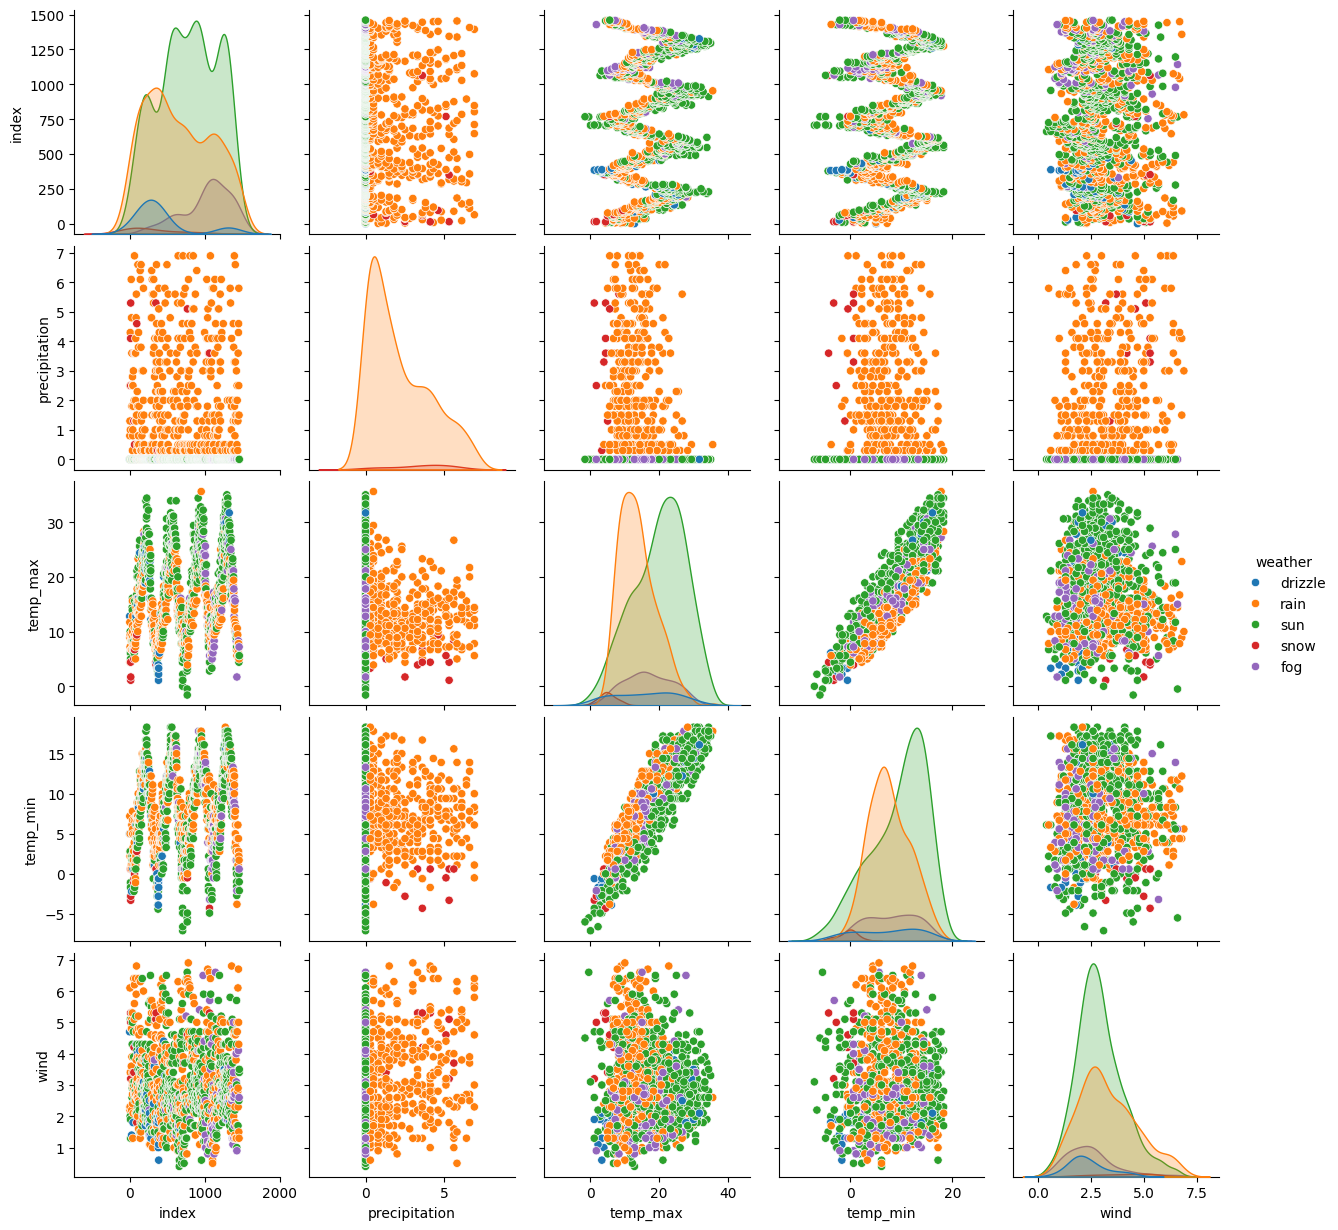

In [43]:
sns.pairplot(data=data,hue="weather")
plt.show()

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [45]:
X=df[["precipitation","temp_max","temp_min","wind"]]
Y=df["weather"]

In [46]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,random_state=42,test_size=.2)

In [47]:
Y_train

1066     fog
638     rain
799     rain
380      sun
303     rain
        ... 
1130    rain
1294     sun
860     rain
1459     sun
1126     fog
Name: weather, Length: 1168, dtype: object

In [48]:
X_train

,precipitation,temp_max,temp_min,wind
1066,0.0,5.6,-3.2,5.7
638,18.5,13.9,10.0,6.3
799,18.8,12.2,6.1,2.2
380,0.0,6.7,-0.6,2.3
303,34.5,15.0,12.2,2.8
...,...,...,...,...
1130,8.4,10.6,4.4,1.7
1294,0.0,33.3,17.8,3.4
860,0.5,15.6,7.2,2.1
1459,0.0,5.6,-1.0,3.4


In [49]:
lg=LogisticRegression()
lg.fit(X_train,Y_train)

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [50]:
lg.predict([[18.5,13.9,10.0,6.3]])

c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array(['rain'], dtype=object)

In [51]:
lg.score(X_test,Y_test),lg.score(X_train,Y_train)

(0.8327645051194539, 0.8493150684931506)

In [52]:
from sklearn.metrics import confusion_matrix

In [53]:
cm=confusion_matrix(Y_test,lg.predict(X_test))

In [22]:
#sns.heatmap(cm)
plt.show()

In [23]:
q1=df["precipitation"].quantile(.25)
q3=df["precipitation"].quantile(.75)
IQR=q3-q1
min=q1-(1.5*IQR)
max=q3+(1.5*IQR)

In [24]:
data=data[(data["precipitation"]>min )&(data["precipitation"]<max)]


In [29]:
Q1=df["wind"].quantile(.25)
Q3=df["wind"].quantile(.75)
IIQR=q3-q1
min1=q1-(1.5*IIQR)
max1=Q3+(1.5*IIQR)

In [31]:
data=data[(data["wind"]>min )&(data["wind"]<max)]


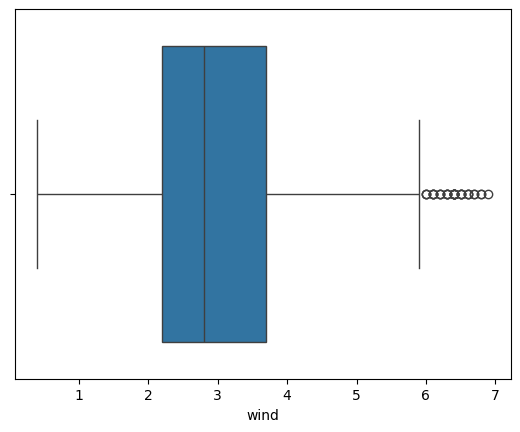

In [32]:
sns.boxplot(x="wind",data=data)
plt.show()

In [41]:
data.reset_index(inplace=True)

In [42]:
data

,index,precipitation,temp_max,temp_min,wind,weather
0,0,0.0,12.8,5.0,4.7,drizzle
1,2,0.8,11.7,7.2,2.3,rain
2,4,1.3,8.9,2.8,6.1,rain
3,5,2.5,4.4,2.2,2.2,rain
4,6,0.0,7.2,2.8,2.3,rain
...,...,...,...,...,...,...
1225,1455,0.0,4.4,0.0,2.5,sun
1226,1457,1.5,5.0,1.7,1.3,rain
1227,1458,0.0,7.2,0.6,2.6,fog
1228,1459,0.0,5.6,-1.0,3.4,sun


In [54]:
from sklearn.tree import DecisionTreeClassifier
dc=DecisionTreeClassifier()

In [57]:
for i in range(1,21):
    dc=DecisionTreeClassifier(max_depth=i)
    dc.fit(X_train,Y_train)
    print(dc.score(X_train,Y_train),dc.score(X_test,Y_test))

0.851027397260274 0.8293515358361775
0.8553082191780822 0.8327645051194539
0.8621575342465754 0.8327645051194539
0.865582191780822 0.8361774744027304
0.8698630136986302 0.8327645051194539
0.8784246575342466 0.8122866894197952
0.8852739726027398 0.7952218430034129
0.8904109589041096 0.7713310580204779
0.9041095890410958 0.7849829351535836
0.9152397260273972 0.7713310580204779
0.9246575342465754 0.7747440273037542
0.9340753424657534 0.7747440273037542
0.9460616438356164 0.7679180887372014
0.9554794520547946 0.764505119453925
0.9606164383561644 0.7781569965870307
0.9691780821917808 0.7679180887372014
0.9768835616438356 0.7474402730375427
0.9871575342465754 0.7337883959044369
0.9888698630136986 0.7406143344709898
0.9922945205479452 0.7337883959044369


In [56]:
dc.score(X_train,Y_train),dc.score(X_test,Y_test)

(0.997431506849315, 0.7303754266211604)

In [58]:
from sklearn.naive_bayes import GaussianNB

In [60]:
gs=GaussianNB()
gs.fit(X_train,Y_train)
gs.score(X_train,Y_train),gs.score(X_test,Y_test)

(0.8544520547945206, 0.8293515358361775)